# Analisi della Pipeline MLOps in Movimento – PENTION-M

In questo notebook analizziamo le prestazioni operative della pipeline MLOps in movimento:

- Latenza end-to-end vista dal client (`e2e_latency_ms`)
- Latenza interna misurata dal servizio di monitoring (`svc_latency_ms`)
- Drift score fisico basato sul monitoraggio PIML (`drift_score`)
- Stabilità del modello e versione (`model_version`)
- Correlazione tra drift, latenza e confidenza del classificatore NPS
- Collegamento con i log di monitoring (`/logs/monitoring_log.jsonl`)

I dati provengono dallo script:

```text
validation/MLOps/mlops_pipeline_stress_test.py
che ha eseguito N simulazioni consecutive verso il servizio mlops_ingestion.

### Import e configurazione

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurazioni grafiche di base
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
RESULTS_CSV = os.path.join(ROOT_DIR, "validation", "MLOps", "mlops_stress_results.csv")
MONITORING_LOG = os.path.join(ROOT_DIR, "logs", "monitoring_log.jsonl")

RESULTS_CSV, MONITORING_LOG

('c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\validation\\MLOps\\mlops_stress_results.csv',
 'c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\logs\\monitoring_log.jsonl')

### Caricamento dei risultati dello stress test

In [2]:
# Carica risultati dallo stress test
df = pd.read_csv(RESULTS_CSV)

print("Numero di run:", len(df))
df.head()

Numero di run: 20


,run_id,simulation_id,t_start_iso,e2e_latency_ms,svc_latency_ms,drift_score,mse_free,stability_index,confidence,model_version,...,mlops_monitoring_cpu,mlops_monitoring_mem,gaussian_dispersion_model_cpu,gaussian_dispersion_model_mem,correction_dispersion_piml_cpu,correction_dispersion_piml_mem,loc_emission_source_piml_cpu,loc_emission_source_piml_mem,clas_nps_cpu,clas_nps_mem
0,1,STRESS_20251127_171846_001,2025-11-27T17:18:47.757097Z,5310.33,14.38,0.0,NaN,4.0,0.782210,PIML_v2,...,0.13,0.23,0.18,0.70,0.22,5.20,0.18,0.9,0.21,3.67
1,2,STRESS_20251127_171853_002,2025-11-27T17:18:55.153984Z,5162.68,13.66,0.0,NaN,4.0,0.892544,PIML_v2,...,0.14,0.23,0.28,0.70,0.22,5.22,0.19,0.9,0.18,3.67
2,3,STRESS_20251127_171900_003,2025-11-27T17:19:02.403504Z,5241.79,15.24,0.0,NaN,4.0,0.968576,PIML_v2,...,0.15,0.23,0.24,0.70,0.22,4.95,0.23,0.9,0.22,3.67
3,4,STRESS_20251127_171907_004,2025-11-27T17:19:09.730360Z,5349.12,12.44,0.0,NaN,4.0,0.925555,PIML_v2,...,0.15,0.23,0.20,0.69,0.23,4.97,0.21,0.9,0.23,3.67
4,5,STRESS_20251127_171915_005,2025-11-27T17:19:16.761175Z,5185.93,15.92,0.0,NaN,4.0,0.344613,PIML_v2,...,0.17,0.23,0.23,0.70,0.22,4.97,0.20,0.9,0.21,3.67


### Pulizia base e overview

In [3]:
# Conversione di alcune colonne numeriche
for col in ["e2e_latency_ms", "svc_latency_ms", "drift_score", "stability_index", "confidence"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtriamo solo le chiamate andate a buon fine
df_ok = df[df["http_status"] == 200].copy()

print("Run totali:", len(df))
print("Run con http_status == 200:", len(df_ok))

df_ok.describe()[["e2e_latency_ms", "svc_latency_ms", "drift_score", "confidence"]]

Run totali: 20
Run con http_status == 200: 20


,e2e_latency_ms,svc_latency_ms,drift_score,confidence
count,20.000000,20.000000,20.000000,20.000000
mean,5163.615000,23.441000,0.450550,0.784308
std,176.509843,7.742123,0.332951,0.204093
min,4687.300000,12.440000,0.000000,0.340566
25%,5082.632500,15.842500,0.106125,0.693459
50%,5198.405000,23.170000,0.500300,0.844201
75%,5257.550000,29.060000,0.715300,0.955523
max,5429.430000,41.190000,0.957800,0.971739


### Boxplot delle latenze

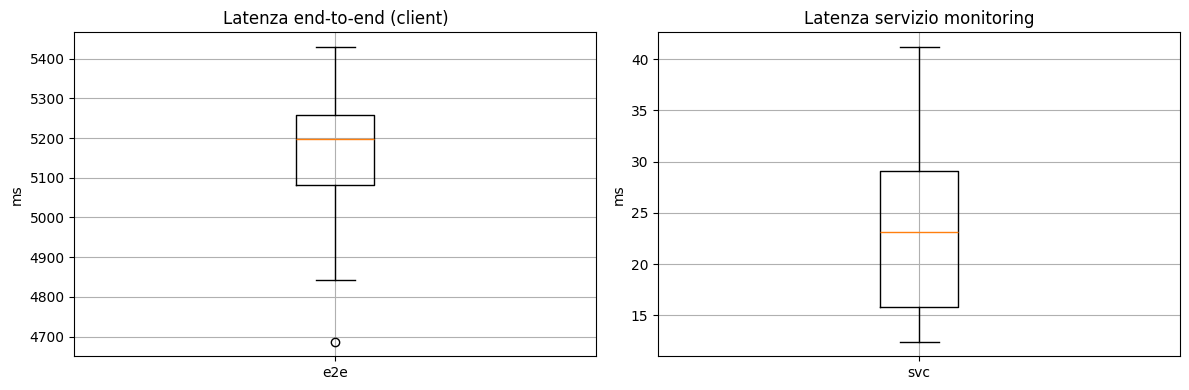

In [ ]:
data = []
labels = []

if "e2e_latency_ms" in df_ok.columns:
    data.append(df_ok["e2e_latency_ms"].dropna())
    labels.append("Client end-to-end")

if "svc_latency_ms" in df_ok.columns:
    data.append(df_ok["svc_latency_ms"].dropna())
    labels.append("Service (monitoring)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_ok["e2e_latency_ms"].dropna())
axes[0].set_title("Latenza end-to-end (client)")
axes[0].set_ylabel("ms")
axes[0].set_xticklabels(["e2e"])

axes[1].boxplot(df_ok["svc_latency_ms"].dropna())
axes[1].set_title("Latenza servizio monitoring")
axes[1].set_ylabel("ms")
axes[1].set_xticklabels(["svc"])

plt.tight_layout()
plt.show()


### Boxplot del drift score

C:\Users\marco\AppData\Local\Temp\ipykernel_21996\2154854674.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])


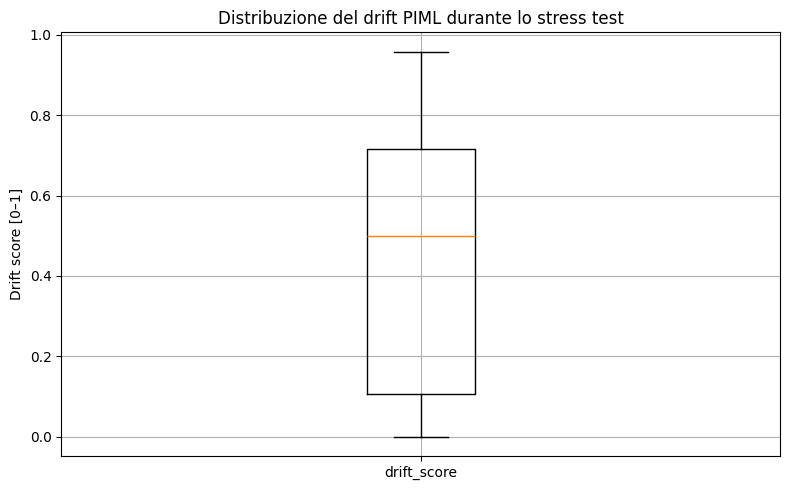

In [5]:
if "drift_score" in df_ok.columns:
    fig, ax = plt.subplots()
    ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])
    ax.set_ylabel("Drift score [0–1]")
    ax.set_title("Distribuzione del drift PIML durante lo stress test")
    plt.tight_layout()
    plt.show()
else:
    print("Colonna 'drift_score' non presente nei risultati.")

### Latenza e drift nel tempo (per run)

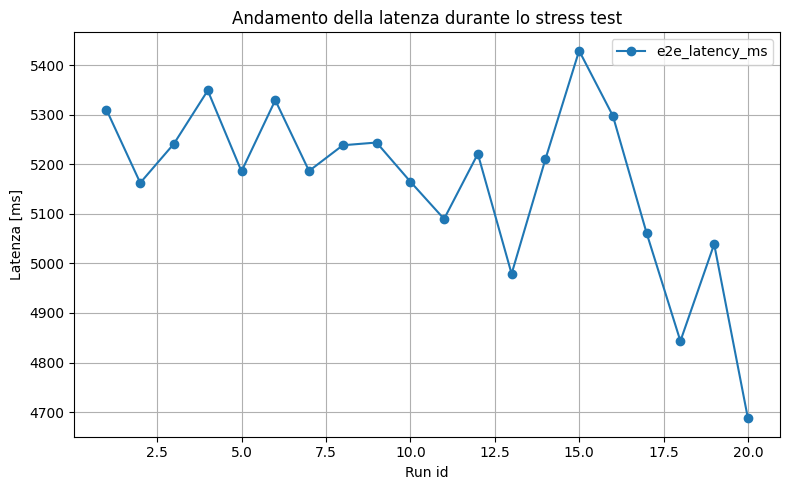

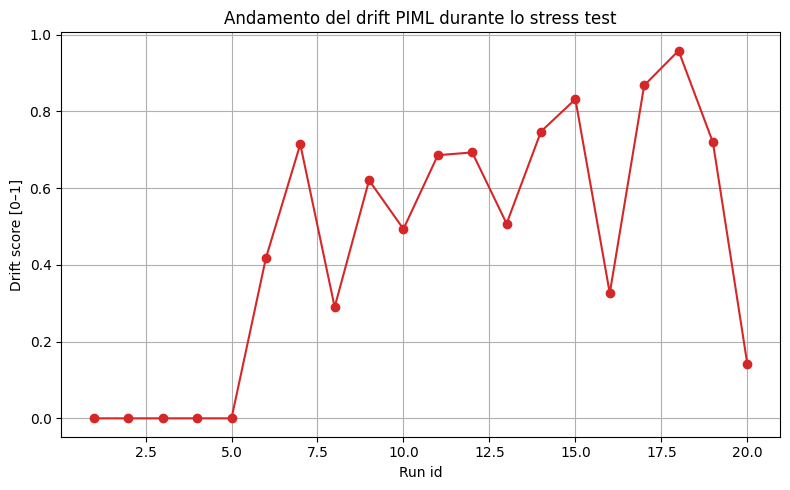

In [6]:
if "run_id" in df_ok.columns:
    x = df_ok["run_id"]

    fig, ax1 = plt.subplots()

    ax1.plot(x, df_ok["e2e_latency_ms"], marker="o", label="e2e_latency_ms")

    ax1.set_xlabel("Run id")
    ax1.set_ylabel("Latenza [ms]")
    ax1.set_title("Andamento della latenza durante lo stress test")
    ax1.legend()

    plt.tight_layout()
    plt.show()

    # Drift in funzione del run
    if "drift_score" in df_ok.columns:
        fig, ax2 = plt.subplots()
        ax2.plot(x, df_ok["drift_score"], marker="o", color="tab:red")
        ax2.set_xlabel("Run id")
        ax2.set_ylabel("Drift score [0–1]")
        ax2.set_title("Andamento del drift PIML durante lo stress test")
        plt.tight_layout()
        plt.show()

### Correlazione tra drift, latenza e confidenza

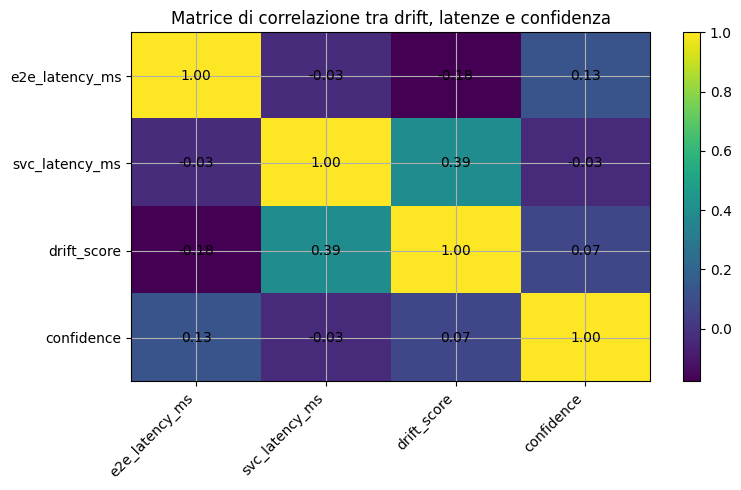

In [7]:
cols_for_corr = []

for col in ["e2e_latency_ms", "svc_latency_ms", "drift_score", "confidence"]:
    if col in df_ok.columns:
        cols_for_corr.append(col)

df_corr = df_ok[cols_for_corr].dropna()

if len(cols_for_corr) >= 2 and not df_corr.empty:
    corr = df_corr.corr()

    fig, ax = plt.subplots()
    im = ax.imshow(corr.values, aspect="auto")

    ax.set_xticks(range(len(cols_for_corr)))
    ax.set_yticks(range(len(cols_for_corr)))
    ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
    ax.set_yticklabels(cols_for_corr)

    for i in range(len(cols_for_corr)):
        for j in range(len(cols_for_corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

    ax.set_title("Matrice di correlazione tra drift, latenze e confidenza")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Non ci sono abbastanza colonne numeriche per calcolare la correlazione.")

### Analisi versioni di modello

Distribuzione dei run per model_version:


model_version
PIML_v2    20
Name: count, dtype: int64

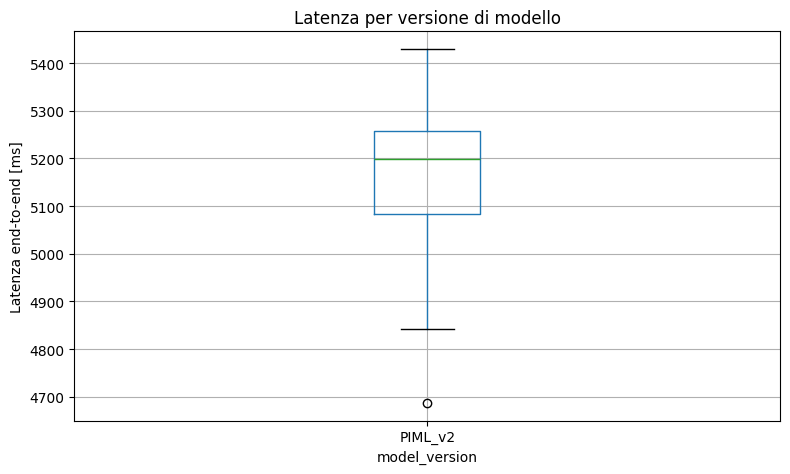

In [8]:
if "model_version" in df_ok.columns:
    print("Distribuzione dei run per model_version:")
    display(df_ok["model_version"].value_counts())

    fig, ax = plt.subplots()
    df_ok.boxplot(column="e2e_latency_ms", by="model_version", ax=ax)
    ax.set_ylabel("Latenza end-to-end [ms]")
    ax.set_title("Latenza per versione di modello")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("Colonna 'model_version' non presente nei risultati.")

### Collegamento con monitoring_log.jsonl (mse_free, drift reale)

In [9]:
def load_monitoring_log(path, last_n=None):
    if not os.path.exists(path):
        print(f"File non trovato: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if last_n is not None and last_n > 0:
        rows = rows[-last_n:]

    return pd.DataFrame(rows)


mon_df = load_monitoring_log(MONITORING_LOG, last_n=500)

print("Righe nel monitoring_log.jsonl:", len(mon_df))
mon_df.tail()

Righe nel monitoring_log.jsonl: 20


,time,simulation_id,model_version,latency_ms,drift_score,mse_free,stability_index,confidence
15,2025-11-27T17:20:40.411734,STRESS_20251127_172033_016,PIML_v2,0,0.3260,2.333921,4.0,0.971739
16,2025-11-27T17:20:47.552003,STRESS_20251127_172040_017,PIML_v2,0,0.8673,2.331598,4.0,0.957998
17,2025-11-27T17:20:54.487029,STRESS_20251127_172047_018,PIML_v2,0,0.9578,2.330930,4.0,0.945007
18,2025-11-27T17:21:00.733630,STRESS_20251127_172054_019,PIML_v2,0,0.7189,2.336210,4.0,0.340566
19,2025-11-27T17:21:07.511908,STRESS_20251127_172100_020,PIML_v2,0,0.1415,2.329030,4.0,0.752990


### Confronto drift e mse_free dal monitoring log

,time,simulation_id,model_version,latency_ms,drift_score,mse_free
10,2025-11-27T17:20:04.555071,STRESS_20251127_171957_011,PIML_v2,0,0.6856,2.329715
11,2025-11-27T17:20:11.837903,STRESS_20251127_172004_012,PIML_v2,0,0.6928,2.332890
12,2025-11-27T17:20:18.910490,STRESS_20251127_172012_013,PIML_v2,0,0.5073,2.329224
13,2025-11-27T17:20:26.198206,STRESS_20251127_172019_014,PIML_v2,0,0.7473,2.333164
14,2025-11-27T17:20:33.007596,STRESS_20251127_172026_015,PIML_v2,0,0.8315,2.337198
15,2025-11-27T17:20:40.411734,STRESS_20251127_172033_016,PIML_v2,0,0.3260,2.333921
16,2025-11-27T17:20:47.552003,STRESS_20251127_172040_017,PIML_v2,0,0.8673,2.331598
17,2025-11-27T17:20:54.487029,STRESS_20251127_172047_018,PIML_v2,0,0.9578,2.330930
18,2025-11-27T17:21:00.733630,STRESS_20251127_172054_019,PIML_v2,0,0.7189,2.336210
19,2025-11-27T17:21:07.511908,STRESS_20251127_172100_020,PIML_v2,0,0.1415,2.329030


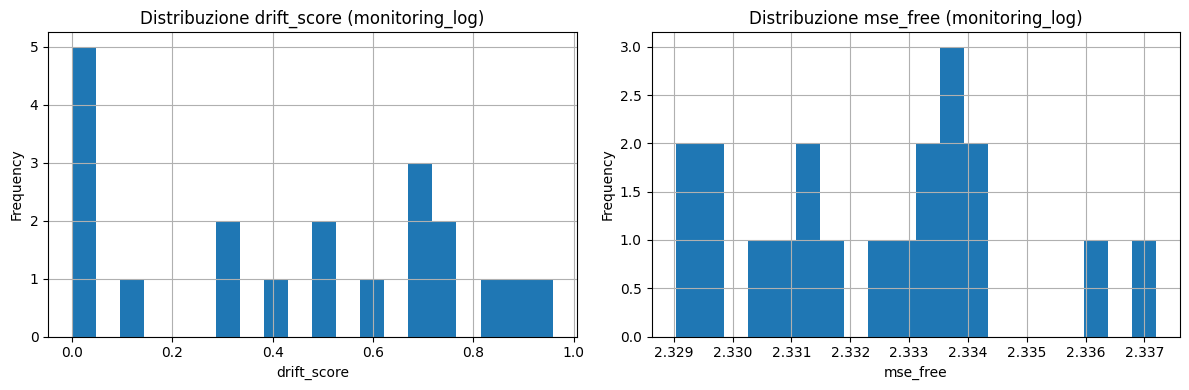

In [10]:
if not mon_df.empty:
    for col in ["latency_ms", "drift_score", "mse_free"]:
        if col in mon_df.columns:
            mon_df[col] = pd.to_numeric(mon_df[col], errors="coerce")

    display(mon_df[["time", "simulation_id", "model_version", "latency_ms", "drift_score", "mse_free"]].tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mon_df["drift_score"].dropna().plot(kind="hist", bins=20, ax=axes[0])
    axes[0].set_title("Distribuzione drift_score (monitoring_log)")
    axes[0].set_xlabel("drift_score")

    mon_df["mse_free"].dropna().plot(kind="hist", bins=20, ax=axes[1])
    axes[1].set_title("Distribuzione mse_free (monitoring_log)")
    axes[1].set_xlabel("mse_free")

    plt.tight_layout()
    plt.show()
else:
    print("monitoring_log vuoto o non disponibile.")

### Sintesi numerica per la tesi

In [11]:
summary = {}

if not df_ok.empty:
    summary["n_runs_ok"] = len(df_ok)
    summary["e2e_latency_ms_mean"] = df_ok["e2e_latency_ms"].mean()
    summary["e2e_latency_ms_p95"] = df_ok["e2e_latency_ms"].quantile(0.95)

    if "svc_latency_ms" in df_ok.columns:
        summary["svc_latency_ms_mean"] = df_ok["svc_latency_ms"].mean()

    if "drift_score" in df_ok.columns:
        summary["drift_score_mean"] = df_ok["drift_score"].mean()
        summary["drift_score_max"] = df_ok["drift_score"].max()

    if "confidence" in df_ok.columns:
        summary["confidence_mean"] = df_ok["confidence"].mean()

summary

{'n_runs_ok': 20,
 'e2e_latency_ms_mean': 5163.615,
 'e2e_latency_ms_p95': 5353.1355,
 'svc_latency_ms_mean': 23.441,
 'drift_score_mean': 0.45055000000000006,
 'drift_score_max': 0.9578,
 'confidence_mean': 0.7843084052205086}